# 决策树实现练习：基于 Gini 系数的分类

本 notebook 按“任务说明 -> 数据准备 -> sklearn 对照实验 -> 手写实现 -> 结果总结”的顺序组织。
重点目标是基于 Gini 系数完成决策树分类，并与信息熵版本进行对照。

In [56]:
import sys
import os
import numpy as np  
import pandas as pd  
import graphviz
from tqdm.auto import tqdm,trange
from sklearn.tree import DecisionTreeClassifier, plot_tree,export_graphviz
import matplotlib.pyplot as plt
from matplotlib import font_manager
from loguru import logger

font_path="/home/lanshi/.local/share/fonts/SourceHanSerifSC-Regular.otf"
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False


logger.remove()

logger.add(
    sink=sys.stderr,
    level="INFO",
    format="<green>{time:YYYY-MM-DD HH:mm:ss.SSS}</green> | "
            "<level>{level:<8}</level> | "
            "<cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - "
            "<level>{message}</level>",
    colorize=True
)
logger.info(plt.rcParams['font.family'])

2026-05-19 20:39:40.850 | INFO     | __main__:<module>:30 - ['Source Han Serif SC']


## 1. 数据准备与预处理

先完成样本构造、特征映射和基础环境配置，为后续对照实验与手写实现做准备。

In [57]:

y = np.array(list('NYYYYYNYYN'))  
logger.info(y)  
X= pd.DataFrame({'日志密度':list('sslmlmmlms'), '好友密度':list('slmmmlsmss'), '真实头像':list('NYYYYNYYYY'), '真实用户':y})  


2026-05-19 20:39:40.935 | INFO     | __main__:<module>:2 - ['N' 'Y' 'Y' 'Y' 'Y' 'Y' 'N' 'Y' 'Y' 'N']


In [58]:
def fit_model(X, y,criterion="entropy"):  
    model = DecisionTreeClassifier(criterion=criterion)  
    model.fit(X, y)  
    return model


In [59]:
# map reflect
X['日志密度']=X['日志密度'].map({
    's':0,'m':1,'l':2
})
X['好友密度']=X['好友密度'].map({
    's':0,'m':1,'l':2
})
X['真实头像']=X['真实头像'].map({
    'N':0,'Y':1
})

X

,日志密度,好友密度,真实头像,真实用户
0,0,0,0,N
1,0,2,1,Y
2,2,1,1,Y
3,1,1,1,Y
4,2,1,1,Y
5,1,2,0,Y
6,1,0,1,N
7,2,1,1,Y
8,1,0,1,Y
9,0,0,1,N


## 2. sklearn 决策树对照实验

这里先用 sklearn 的实现作为基线，分别对信息熵和 Gini 系数两种划分标准进行对照。

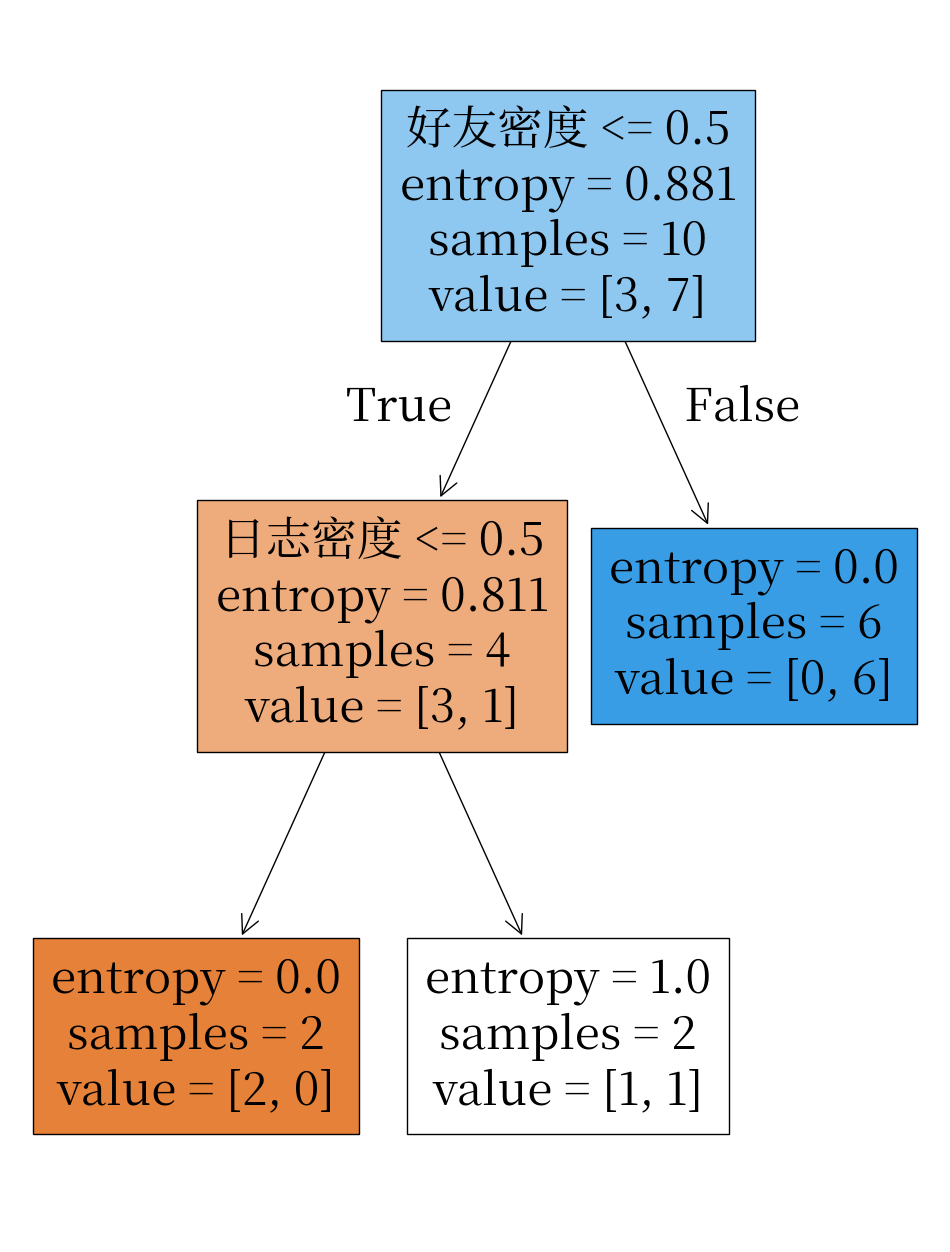

In [60]:
model=fit_model(X.drop(columns='真实用户'),y)
plt.rcParams['font.family']=prop.get_name()
plt.figure(figsize=(12,16))
fn=X.columns
_=plot_tree(model,filled=True,feature_names=fn)
plt.savefig('data/account.svg')

In [61]:


model=fit_model(X.drop(columns='真实用户'),y)

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=X.drop(columns='真实用户').columns.tolist(),
    class_names=np.unique(y).tolist(),
    filled=True,
    rounded=True
)

graph = graphviz.Source(dot_data)
graph.render('data/Account', format='svg',cleanup=True)

'data/Account.svg'

## 3. 手写决策树实现

下面开始根据课堂思路手写决策树的分裂过程，先完成信息熵版本，再切换到 Gini 系数版本。

In [62]:
s=X['真实用户']
p=s.value_counts()/s.size
(p*np.log2(1/p)).sum()

np.float64(0.8812908992306926)

In [63]:
x=X['日志密度'].unique()
x.sort()

In [64]:
for i in range(len(x)-1):
    split=x[i:i+2].mean()
    cond=X['日志密度']<=split
    p=cond.value_counts()/cond.size
    indexs=p.index
    entropy=0
    for index in indexs:
        user=X[cond==index]['真实用户']
        p_user=user.value_counts()/user.size
        entropy+=(p_user*np.log2(1/p_user)).sum()*p[index]
    logger.info(f"split={split}, entropy={entropy}")

2026-05-19 20:39:46.967 | INFO     | __main__:<module>:11 - split=0.5, entropy=0.689659695223976
2026-05-19 20:39:46.969 | INFO     | __main__:<module>:11 - split=1.5, entropy=0.689659695223976


In [65]:
columns=['日志密度','好友密度','真实头像']
lower_entropy=1
condition={}
for col in tqdm(columns,desc="Epochs",position=0,leave=True):
    x=X[col].unique()
    x.sort()
    logger.info(x)
    for i in trange(len(x)-1,desc="Batches",position=1,leave=False):
        split=x[i:i+2].mean()
        cond=X[col]<=split
        p=cond.value_counts()/cond.size
        index=p.index
        entropy=0
        for index in tqdm(indexs,desc="steps",position=2,leave=False):
            user=X[cond==index]['真实用户']
            p_user=user.value_counts()/user.size
            entropy+=(p_user*np.log2(1/p_user)).sum()*p[index]
        logger.info(col,split,entropy)
        if entropy<lower_entropy:
            condition.clear()
            lower_entropy=entropy
            condition[col]=split
logger.info(f"the best condition is {condition}")
    

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

2026-05-19 20:39:47.132 | INFO     | __main__:<module>:7 - [0 1 2]


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:47.138 | INFO     | __main__:<module>:18 - 日志密度


...

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:47.150 | INFO     | __main__:<module>:18 - 好友密度
2026-05-19 20:39:47.150 | INFO     | __main__:<module>:7 - [0 1]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:47.155 | INFO     | __main__:<module>:18 - 真实头像
2026-05-19 20:39:47.156 | INFO     | __main__:<module>:23 - the best condition is {'好友密度': np.float64(0.5)}


In [66]:
cond=X['好友密度']<0.5
X_=X[cond]
columns=['日志密度','真实头像']
lower_entropy=1
condition={}
for col in tqdm(columns,desc="进一步筛选",position=0,leave=True):
    x=X_[col].unique()
    x.sort()
    logger.info(x)
    for i in trange(len(x)-1,desc="每一列",position=1,leave=False):
        split=x[i:i+2].mean()
        cond=X_[col]<=split;
        p=cond.value_counts()/cond.size
        indexs=p.index
        entropy=0
        for index in tqdm(indexs,desc="steps",position=2,leave=False):
            user=X_[cond==index]['真实用户']
            p_user=user.value_counts()/user.size
            entropy+=(p_user*np.log2(1/p_user)).sum()*p[index]
        logger.info(f"{col},{split},{entropy}")
        if entropy<lower_entropy:
            condition.clear()
            lower_entropy=entropy
            condition[col]=split
logger.info(f"the best condition is :{condition}")
        

进一步筛选:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:48.127 | INFO     | __main__:<module>:9 - [0 1]


每一列:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:48.134 | INFO     | __main__:<module>:20 - 日志密度,0.5,0.5
2026-05-19 20:39:48.135 | INFO     | __main__:<module>:9 - [0 1]


每一列:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:48.142 | INFO     | __main__:<module>:20 - 真实头像,0.5,0.6887218755408671
2026-05-19 20:39:48.142 | INFO     | __main__:<module>:25 - the best condition is :{'日志密度': np.float64(0.5)}


### 2.2 Gini 系数基线

先用 sklearn 的 Gini 版本作为对照，观察它与信息熵版本在分裂结果上的差异。

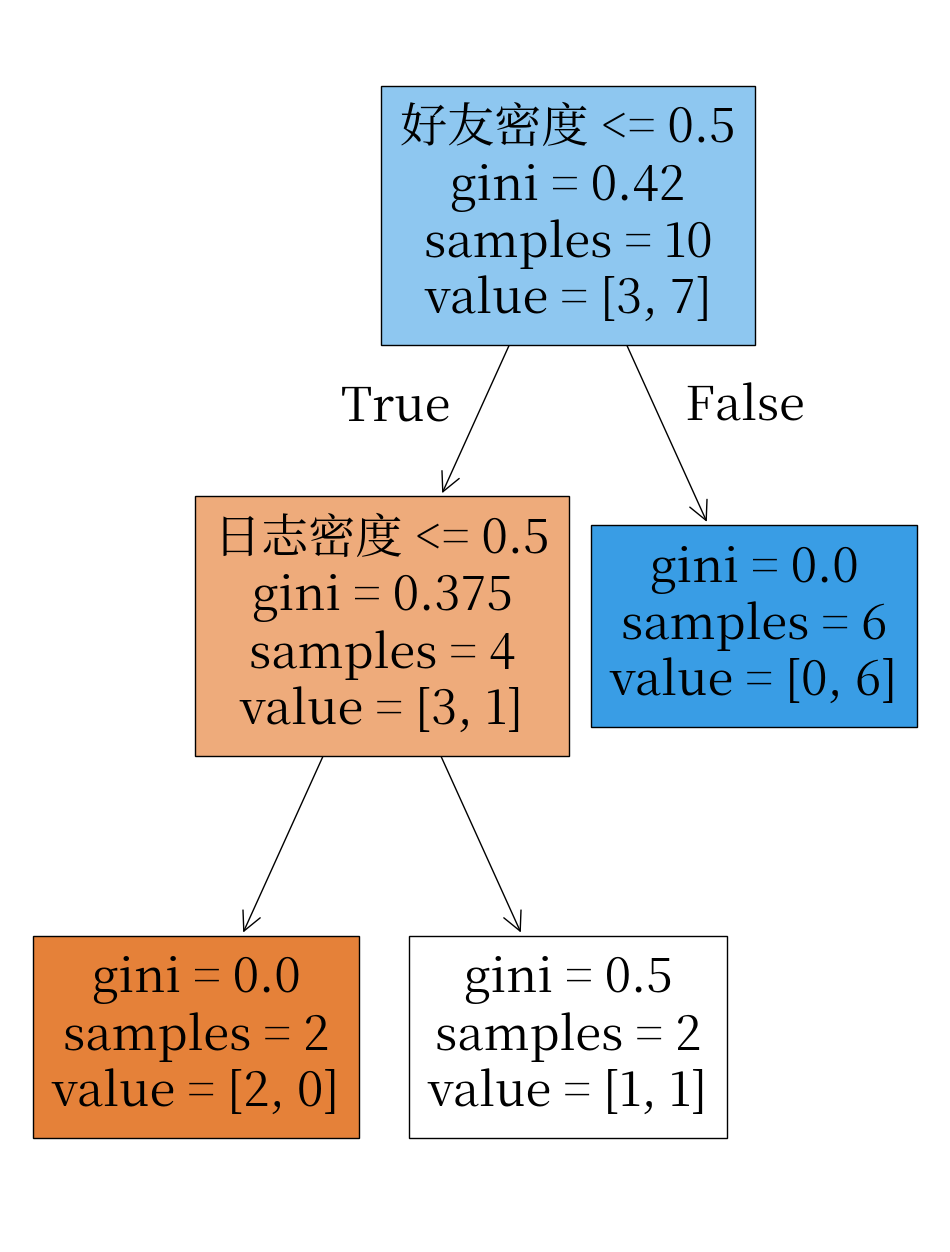

In [67]:
model=fit_model(X.drop(columns='真实用户'),y,"gini")
plt.rcParams['font.family']=prop.get_name()
plt.figure(figsize=(12,16))
fn=X.columns
_=plot_tree(model,filled=True,feature_names=fn)
plt.savefig('data/account_gini.svg')

### 3.2 Gini 系数实现

在完成信息熵版本后，再把分裂准则切换为 Gini 系数，验证同样的选点策略是否成立。

In [68]:
# 手写gini决策树
columns=['日志密度','好友密度','真实头像']
lower_gini=1
condition={}
for col in tqdm(columns,desc="Epochs",position=0,leave=True):
    x=X[col].unique()
    x.sort()
    logger.info(x)
    for i in trange(len(x)-1,desc="Batches",position=1,leave=False):
        split=x[i:i+2].mean()
        cond=X[col]<=split
        p=cond.value_counts()/cond.size
        gini_total=0
        for branch_val in tqdm(p.index,desc="steps",position=2,leave=False):
            # 获取当前分支的目标变量数据
            user=X[cond==branch_val]['真实用户']
            if user.size == 0: continue
            
            p_user=user.value_counts()/user.size
            # 计算当前子节点的基尼系数并加入权重预测
            node_gini = (p_user*(1-p_user)).sum()
            gini_total += p[branch_val] * node_gini
            
        logger.info(f"Col: {col}, Split: {split}, Gini: {gini_total}")
        
        # 寻找最小化加权基尼系数的分割点
        if gini_total < lower_gini:
            condition.clear()
            lower_gini=gini_total
            condition[col]=split
logger.info(f"the best condition is {condition}")
    

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

2026-05-19 20:39:54.762 | INFO     | __main__:<module>:8 - [0 1 2]


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:54.768 | INFO     | __main__:<module>:24 - Col: 日志密度, Split: 0.5, Gini: 0.3047619047619048


...

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:54.781 | INFO     | __main__:<module>:24 - Col: 好友密度, Split: 1.5, Gini: 0.375
2026-05-19 20:39:54.782 | INFO     | __main__:<module>:8 - [0 1]


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:54.788 | INFO     | __main__:<module>:24 - Col: 真实头像, Split: 0.5, Gini: 0.4
2026-05-19 20:39:54.789 | INFO     | __main__:<module>:31 - the best condition is {'好友密度': np.float64(0.5)}


In [69]:
cond = X['好友密度'] < 0.5
X_ = X[cond]

columns = ['日志密度', '真实头像']
lower_gini = 1
condition = {}

for col in tqdm(columns, desc="进一步筛选", position=0, leave=True):
    x = X_[col].unique()
    x.sort()
    logger.info(x)

    for i in trange(len(x) - 1, desc="每一列", position=1, leave=False):
        split = x[i:i+2].mean()
        split_mask = X_[col] <= split
        p = split_mask.value_counts() / split_mask.size

        gini = 0
        for branch in tqdm(p.index, desc="steps", position=2, leave=False):
            user = X_[split_mask == branch]['真实用户']
            if user.size == 0:
                continue
            p_user = user.value_counts() / user.size
            gini += (1 - (p_user ** 2).sum()) * p[branch]

        logger.info(f"col:{col},split:{split},gini:{gini}")
        if gini < lower_gini:
            condition.clear()
            lower_gini = gini
            condition[col] = split

logger.info(f"the best condition is :{condition}")
        

进一步筛选:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:55.309 | INFO     | __main__:<module>:11 - [0 1]


每一列:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:55.315 | INFO     | __main__:<module>:26 - col:日志密度,split:0.5,gini:0.25
2026-05-19 20:39:55.315 | INFO     | __main__:<module>:11 - [0 1]


每一列:   0%|          | 0/1 [00:00<?, ?it/s]

steps:   0%|          | 0/2 [00:00<?, ?it/s]

2026-05-19 20:39:55.322 | INFO     | __main__:<module>:26 - col:真实头像,split:0.5,gini:0.3333333333333333
2026-05-19 20:39:55.322 | INFO     | __main__:<module>:32 - the best condition is :{'日志密度': np.float64(0.5)}


## 4. 结果总结

本 notebook 先用 sklearn 建立对照，再分别手写信息熵与 Gini 系数版本，便于检查分裂准则、最优切分点和最终树结构是否一致。